# Exercise 3: KNN and the Bias–Variance Tradeoff


```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activity works
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_03/exercise_03_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_03/exercise_03_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps the embedded
activity for a link back to this page.
```

## What this notebook covers

This is Exercise 3 of *Machine Learning for Neuroscience*. **K-nearest
neighbours (KNN)** predicts a new participant's outcome from the outcomes of
the training participants who look most similar:

- for **regression**, KNN averages the outcome of the `k` nearest training
  participants;
- KNN can also do **classification**, voting among the `k` nearest labels
  instead of averaging -- you will see that later; this notebook is
  regression only.

This practice uses `k` -- the number of neighbours -- to make the
**bias–variance tradeoff** concrete: a small `k` is flexible (low bias,
high variance); a large `k` is smooth (higher bias, low variance).

In this notebook you will:

1. reuse Exercise 2's modelling table, target, feature recipe, and locked
   train/test split;
2. fit one standardized KNN regression workflow with `k` chosen by
   training-only cross-validation, and compare it with Exercise 2's linear
   regression on the exact same data;
3. compare honest evaluation with resubstitution and with a deliberately
   invalid leakage score, the same way Exercise 2 did;
4. see the classic bias–variance tradeoff as a labelled, conceptual
   curve;
5. compute an empirical curve, from this dataset, of fitting and validation
   error across every `k` from 1 to every participant in a development
   fitting set;
6. explore that curve yourself with a browser activity.

**Prerequisites:** Exercise 2's train/test workflow, R² and MSE, and
`Pipeline` / `fit` / `predict` in scikit-learn.


## 1. The modelling table

This is the same ABIDE-II modelling table Exercise 2 uses: one **row per
participant**, phenotype columns (including the target, `age`), and brain
columns (`fsCT`, `fsArea`, `fsVol`, `fsLGI`, one HCP-MMP1 cortical region per
hemisphere). See Exercise 2 for the full provenance and column-by-column
discussion; this notebook only reloads the table and previews it.


In [1]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- two public CSVs pinned to an immutable commit, merged on the
# participant id. Nothing here is repository-specific. Same data, provenance,
# and merge as Exercise 2.
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

brain = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
brain = brain.loc[:, [c for c in brain.columns if not str(c).startswith("Unnamed")]]
phen = pd.read_csv(f"{BASE}/abide2_phenotypic.csv", encoding="latin-1", low_memory=False)
phen.columns = phen.columns.str.strip()

KEEP_PHEN = ["FIQ", "VIQ", "PIQ", "SRS_TOTAL_RAW", "ADOS_G_TOTAL", "ADI_R_SOCIAL_TOTAL_A"]
model_df = brain.merge(phen[["SUB_ID", *KEEP_PHEN]], left_on="subject", right_on="SUB_ID", how="left")
model_df = model_df.drop(columns=["SUB_ID"])

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
print(f"modelling table: {model_df.shape[0]} participants x {model_df.shape[1]} columns")

modelling table: 1004 participants x 1452 columns


In [2]:
# A compact preview only -- Exercise 2 already covers this table in full.
preview_cols = ["subject", "site", "group", "age", "sex", "fsCT_L_46_ROI"]
display(model_df[preview_cols].head(3))
print("age available for", int(model_df["age"].notna().sum()), "of", len(model_df), "participants")

,subject,site,group,age,sex,fsCT_L_46_ROI
0,29293,ABIDEII-KKI_1,1.0,8.893151,2.0,2.366
1,28997,ABIDEII-OHSU_1,1.0,12.000000,2.0,2.579
2,28845,ABIDEII-GU_1,2.0,8.390000,1.0,2.690


age available for 1004 of 1004 participants


## 2. One standard KNN regression workflow

**Target:** `age`, in years -- Exercise 2's main outcome. **Features:** the
exact same recipe as Exercise 2's canonical example -- every eligible
bilateral cortical-thickness (`fsCT`) region, 358 features. **Split:** the
exact same locked 75/25 train/test split as Exercise 2
(`train_test_split(test_size=0.25, random_state=42, stratify=group)`),
re-derived here from the same data so it lands on the identical 753
training and 251 test participants.

KNN regression predicts

$$\hat{y}(x_0)=\frac{1}{k}\sum_{i\in\mathcal{N}_k(x_0)}y_i,$$

the average outcome of the `k` training participants whose **features** are
closest to $x_0$. The neighbourhood is found using predictors only -- a new
participant's `age` is never used to find their neighbours.

Feature scaling matters here more directly than it did for linear
regression: KNN measures distance in feature space, and an unscaled feature
with large numeric range would dominate that distance just because of its
units, not because it is more informative. `StandardScaler` belongs inside
the `Pipeline` and must be fit on the training data only, exactly like
Exercise 2.

**A short note on dimensionality.** In very high-dimensional feature spaces,
most pairs of points end up roughly equally far apart, so "nearest
neighbour" can stop meaning much -- the *curse of dimensionality*. This
recipe's 358 standardized features are not astronomically high-dimensional
for 753 training rows, and the audit below found KNN works well here; a
higher-dimensional recipe or a smaller sample could behave differently.

`k` here was **not** chosen by looking at the test set. A deterministic
audit script (`scripts/knn_model_audit.py`) selected it with 5-fold
cross-validation **on the training partition only**, then this notebook
evaluates that one locked choice on the untouched test set exactly once. See
the WP13 report for the complete audit table.


In [3]:
# The full set of eligible cortical-thickness columns -- identical recipe and
# code to Exercise 2's Section 2.
ASYMMETRIC_ROIS = ("_5L_ROI", "_5R_ROI")
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_") and not c.endswith(ASYMMETRIC_ROIS)]
assert all(c.startswith("fsCT_") for c in FEATURES)           # brain-only
assert "age" not in FEATURES and "FIQ" not in FEATURES        # no target / phenotype leakage
print(f"{len(FEATURES)} features, e.g. {FEATURES[:3]}")

358 features, e.g. ['fsCT_L_V1_ROI', 'fsCT_L_MST_ROI', 'fsCT_L_V6_ROI']


In [4]:
# Brain-only X and target y, then the SAME fixed, stratified split as
# Exercise 2 (groups is carried through only so Section 5 can re-split the
# training partition later; it does not change X_train/X_test/y_train/y_test).
has_age = model_df["age"].notna()
X = model_df.loc[has_age, FEATURES].to_numpy(float)
y = model_df.loc[has_age, "age"].to_numpy(float)
groups = model_df.loc[has_age, "group"].to_numpy()      # 1 = autism, 2 = control

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=42, stratify=groups
)
print(f"n_train = {len(y_train)}   n_test = {len(y_test)}   n_features = {X.shape[1]}")

n_train = 753   n_test = 251   n_features = 358


```{admonition} Think first
:class: note
Exercise 2's linear regression scored held-out R² = 0.475 on this exact
split and feature set. Before running KNN: do you expect it to score
higher, lower, or about the same -- and why? (Hint: think about what each
model assumes about how brain structure relates to age.)
```

In [5]:
K_SELECTED = 15  # chosen by 5-fold cross-validation on the TRAINING
                 # partition only -- see scripts/knn_model_audit.py and the
                 # WP13 report for the full audit table. The test set below
                 # is touched exactly once, after k is already fixed.
knn_model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=K_SELECTED))
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
print(f"k = {K_SELECTED}")
print(f"held-out R^2 = {test_r2:.3f}")
print(f"held-out MSE = {test_mse:.1f}  (RMSE {test_mse**0.5:.1f} years)")

k = 15
held-out R^2 = 0.647
held-out MSE = 33.0  (RMSE 5.7 years)


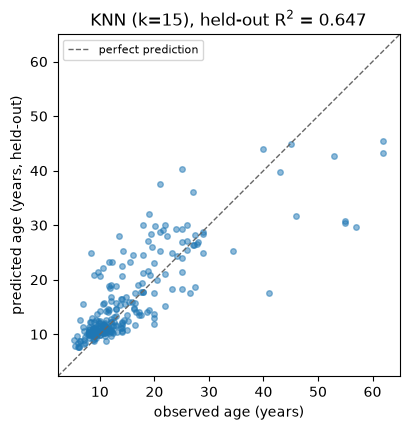

In [6]:
# Observed vs predicted on the test set, with the perfect-prediction diagonal.
fig, ax = plt.subplots(figsize=(4.4, 4.4))
lims = [min(y_test.min(), y_pred.min()) - 3, max(y_test.max(), y_pred.max()) + 3]
ax.plot(lims, lims, "--", color="0.4", lw=1, label="perfect prediction")
ax.scatter(y_test, y_pred, s=16, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("observed age (years)"); ax.set_ylabel("predicted age (years, held-out)")
ax.set_title(f"KNN (k={K_SELECTED}), held-out R$^2$ = {test_r2:.3f}")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

A few things to hold onto:

- KNN with `k = 15` scores a genuinely **positive held-out R²** on this
  recipe -- no curse-of-dimensionality problem here;
- unlike the linear-regression hyperplane, KNN makes no assumption about the
  *shape* of the relationship between features and age -- it only assumes
  that similar brain measurements go with similar ages;
- this is still a random-participant split from the same 17 ABIDE-II sites,
  so it says nothing about generalisation to a new scanner or site.

**Compared with Exercise 2.** On these exact same 753 training and 251 test
participants, the exact same 358-feature recipe, and the exact same target:


In [7]:
# For comparison only -- exact same split/recipe/target as Exercise 2's
# Section 2, refit here so the comparison is self-contained.
ols_compare = make_pipeline(StandardScaler(), LinearRegression())
ols_compare.fit(X_train, y_train)
ols_r2 = r2_score(y_test, ols_compare.predict(X_test))
print(f"Exercise 2 linear regression   held-out R^2 = {ols_r2:.3f}")
print(f"This notebook's KNN (k={K_SELECTED})    held-out R^2 = {test_r2:.3f}")

Exercise 2 linear regression   held-out R^2 = 0.475
This notebook's KNN (k=15)    held-out R^2 = 0.647


KNN scores higher than linear regression **on this specific recipe and
dataset**. That is one comparison, not a universal claim that KNN beats
linear regression -- a different feature set, sample size, or outcome could
easily reverse it. What it does show is that a non-parametric method with no
assumption about the relationship's shape found real, usable structure here.


## 3. Honest evaluation versus invalid alternatives

Same fixed split, same `k = 15`, same 358-feature recipe. Three numbers,
exactly like Exercise 2's Section 3:

| | fit on | evaluate on | what it estimates |
|---|---|---|---|
| **A. Correct** | training rows | untouched test rows | performance on new participants |
| **B. Training score** | training rows | those same training rows | how well it fits data it has seen (a diagnostic, not a generalisation estimate) |
| **C. Invalid** | **test rows** | those same test rows | nothing usable -- the data used to fit cannot also give an honest score |

```{admonition} Think first
:class: note
Predict the order of the three R² values from largest to smallest, and
say why.
```

In [8]:
# A: correct (already computed above) -> reuse `knn_model`, `y_test`, `y_pred`.
# B: resubstitution
train_r2 = r2_score(y_train, knn_model.predict(X_train))
train_mse = mean_squared_error(y_train, knn_model.predict(X_train))

# C: a DELIBERATELY INVALID model -- fit on the test rows, scored on the same
# test rows. Named so it cannot be reused by accident.
invalid_test_fitted_model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=K_SELECTED))
invalid_test_fitted_model.fit(X_test, y_test)
invalid_pred = invalid_test_fitted_model.predict(X_test)
invalid_r2 = r2_score(y_test, invalid_pred)
invalid_mse = mean_squared_error(y_test, invalid_pred)

scores = pd.DataFrame(
    {
        "fit on": ["training rows", "training rows", "test rows (INVALID)"],
        "evaluated on": ["test rows", "training rows", "same test rows"],
        "R^2": [test_r2, train_r2, invalid_r2],
        "MSE": [test_mse, train_mse, invalid_mse],
    },
    index=["A. correct", "B. training score", "C. invalid"],
)
print(f"k = {K_SELECTED}")
scores.round(3)

k = 15


,fit on,evaluated on,R^2,MSE
A. correct,training rows,test rows,0.647,32.989
B. training score,training rows,training rows,0.659,29.768
C. invalid,test rows (INVALID),same test rows,0.650,32.685


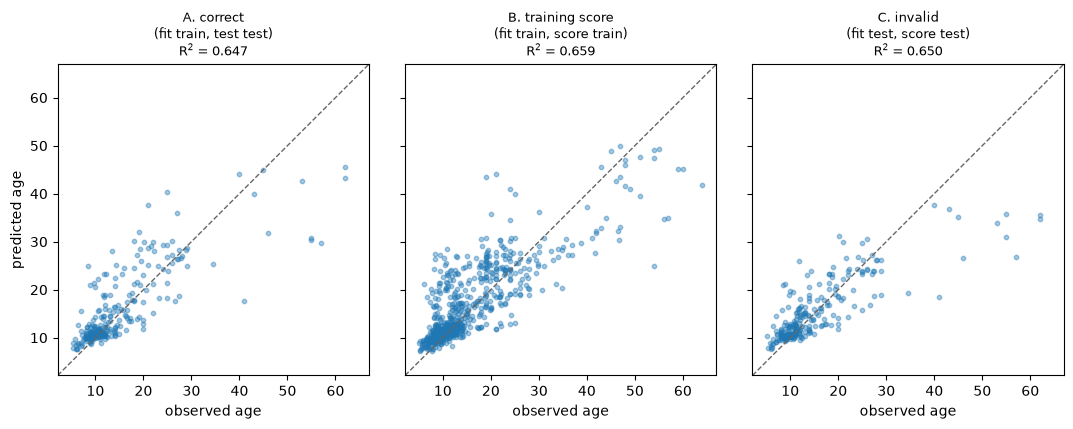

In [9]:
panels = [
    ("A. correct\n(fit train, test test)", y_test, y_pred, test_r2),
    ("B. training score\n(fit train, score train)", y_train, knn_model.predict(X_train), train_r2),
    ("C. invalid\n(fit test, score test)", y_test, invalid_pred, invalid_r2),
]
allv = np.concatenate([y_train, y_test, y_pred, knn_model.predict(X_train), invalid_pred])
lims = [allv.min() - 3, allv.max() + 3]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.9), sharex=True, sharey=True)
for ax, (title, obs, pred, r2) in zip(axes, panels):
    ax.plot(lims, lims, "--", color="0.4", lw=1)
    ax.scatter(obs, pred, s=10, alpha=0.4)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_title(f"{title}\nR$^2$ = {r2:.3f}", fontsize=9)
    ax.set_xlabel("observed age")
axes[0].set_ylabel("predicted age")
plt.tight_layout(); plt.show()

- **A, B and C are close together here** (all around 0.65) -- `k = 15`
  averages over enough neighbours that resubstitution is not very
  optimistic, and the invalid fit-on-test-score-on-test model is not very
  unstable either, since 15 neighbours out of 251 test rows is a small
  fraction. This is a fairer, less dramatic picture than Exercise 2's OLS
  example, where B and C were far above A.
- B evaluates the model on its training data, whereas A and C are evaluated
  on the test data. A is the only valid estimate of performance on unseen
  participants; C is invalid because the test data were used for fitting.
- The ordering can still be read off correctly: C ≥ B > A, because C and
  B both got to look at the rows they are scored on and A did not -- the
  *size* of the gap is what changed, not its direction.

```{dropdown} Check your reasoning: the ordering
C (invalid) is highest because the 251 test rows both fit and grade
themselves. B (training) is next: the model saw these 753 rows while
fitting. A (correct) is lowest because the test rows had no influence on the
model at all -- it is the only number that estimates anything about
participants the model has not seen. All three stay close here because
`k = 15` limits how much any one neighbourhood can overfit a small group of
rows; a more extreme `k` makes the same ordering far more dramatic, as the
next cell shows.
```

### A sharper illustration: resubstitution at k = 1

At `k = 15` the optimism in B and C is real but modest. A more extreme
choice of `k` makes the *mechanism* unmistakable. This is a small,
explicitly labelled demonstration -- **not** a replacement for the honest
`k = 15` model reported above.


In [10]:
# A DELIBERATELY EXTREME demonstration, k=1: every observation is its own
# nearest neighbour, so any model fit and scored on the SAME rows reproduces
# them exactly, by construction -- not because it learned anything.
knn_demo_k1 = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1))
knn_demo_k1.fit(X_train, y_train)
a_k1_r2 = r2_score(y_test, knn_demo_k1.predict(X_test))
b_k1_r2 = r2_score(y_train, knn_demo_k1.predict(X_train))

invalid_test_fitted_model_k1 = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1))
invalid_test_fitted_model_k1.fit(X_test, y_test)
c_k1_r2 = r2_score(y_test, invalid_test_fitted_model_k1.predict(X_test))

print("k = 1")
print(f"A. correct (held-out)          R^2 = {a_k1_r2:.3f}")
print(f"B. training score (resub)      R^2 = {b_k1_r2:.3f}")
print(f"C. invalid (fit+score on test) R^2 = {c_k1_r2:.3f}")

k = 1
A. correct (held-out)          R^2 = 0.553
B. training score (resub)      R^2 = 1.000
C. invalid (fit+score on test) R^2 = 1.000


At `k = 1`, **B and C are both a perfect 1.000** -- every fitted point is
its own nearest neighbour, at distance zero, so the prediction equals the
observation exactly. **A is lower than the `k = 15` model** (0.553 vs.
0.647): a single nearest neighbour is a noisy, high-variance predictor on
genuinely new participants. `k = 1`'s perfect training score is not evidence
of good generalisation -- it is the clearest possible illustration that it
is not.

`invalid_test_fitted_model_k1` (like `invalid_test_fitted_model` above) is
never reused after this cell.


## 4. The classic bias–variance tradeoff

For a model $\hat f$ predicting outcome $Y$ from features $X$, the expected
squared prediction error on a new observation decomposes as

$$\mathbb{E}\left[(Y-\hat f(X))^2\right]
=\operatorname{Bias}(\hat f(X))^2
+\operatorname{Var}(\hat f(X))
+\sigma^2.$$

For KNN, `k` controls flexibility directly:

- **small `k`** -> high flexibility, low bias, high variance (the model
  chases whichever few neighbours happened to be closest);
- **large `k`** -> low flexibility, higher bias, lower variance (the model
  averages over so many neighbours it stops reacting to any one of them);
- **training error alone** keeps falling as flexibility increases (Section
  3 showed `k = 1` reaching a perfect training score), so it favours
  excessive flexibility and cannot be used to choose `k`;
- **expected test error** is minimised at some intermediate flexibility,
  where the falling bias² and the rising variance trade off against each
  other.

The curve below is a **labelled, conceptual illustration** of that
tradeoff -- smooth idealised curves, not a measurement from the ABIDE data.
Section 5 computes the analogous curve *from this dataset*.


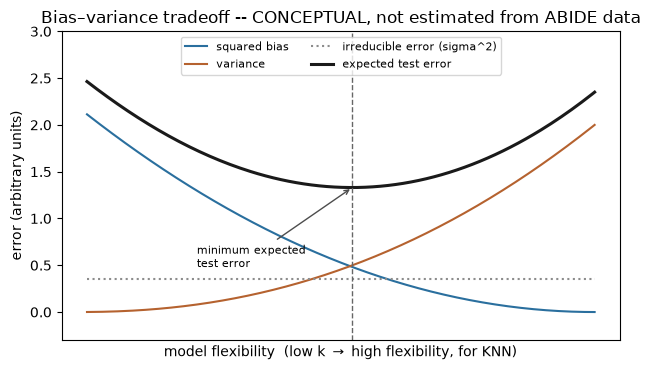

In [11]:
# CONCEPTUAL illustration only -- smooth idealised curves, not measured from
# the ABIDE data. Section 5 computes the empirical analogue.
flexibility = np.linspace(0.02, 1, 200)          # 0 = very smooth, 1 = very flexible
bias_sq = (1 - flexibility) ** 2 * 2.2
variance = flexibility ** 2.2 * 2.0
irreducible = np.full_like(flexibility, 0.35)
expected_test_error = bias_sq + variance + irreducible

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(flexibility, bias_sq, label="squared bias", color="#2a6f9e")
ax.plot(flexibility, variance, label="variance", color="#b5622f")
ax.plot(flexibility, irreducible, label="irreducible error (sigma^2)", color="0.55", ls=":")
ax.plot(flexibility, expected_test_error, label="expected test error", color="0.1", lw=2.2)
best = flexibility[np.argmin(expected_test_error)]
ax.axvline(best, color="0.4", lw=1, ls="--")
ax.annotate("minimum expected\ntest error", xy=(best, expected_test_error.min()),
            xytext=(best - 0.30, expected_test_error.min() - 0.85), fontsize=8,
            arrowprops=dict(arrowstyle="->", color="0.3"))
ax.set_xlabel("model flexibility  (low k $\\to$ high flexibility, for KNN)")
ax.set_ylabel("error (arbitrary units)")
ax.set_title("Bias\u2013variance tradeoff -- CONCEPTUAL, not estimated from ABIDE data")
ax.set_xticks([])
ax.set_ylim(-0.3, 3.0)
ax.legend(fontsize=8, loc="upper center", ncol=2)
plt.tight_layout(); plt.show()

## 5. From k = 1 to every participant: an empirical curve

This section builds a **separate, deterministic development demonstration**
using only the outer-**training** partition (`X_train`, `y_train`, 753
rows) -- the outer test set from Sections 2–3 is never touched here.

Split the training partition itself into a **fitting subset** and a
**validation subset**:

> `N_fit` = number of participants used to fit KNN in this demonstration.

Every integer `k` from 1 through `N_fit` is evaluated on both the fitting
subset (resubstitution) and the validation subset, using the
sort-distances-once-then-cumulative-sum trick (Section 6 reuses the same
idea, and its plain-language description, in the browser).


In [12]:
FIT_TEST_SIZE = 0.25
FIT_RANDOM_STATE = 7   # independent of the outer split's random_state=42
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=FIT_TEST_SIZE, random_state=FIT_RANDOM_STATE, stratify=groups_train
)
N_FIT = len(y_fit)
N_VAL = len(y_val)
print(f"N_fit = {N_FIT}   N_val = {N_VAL}   (from the {len(y_train)}-row outer-training partition only)")

N_fit = 564   N_val = 189   (from the 753-row outer-training partition only)


In [13]:
# Scale using the fitting subset only, then sort each query point's distances
# to every fitting point ONCE and derive predictions for every k from a
# cumulative mean -- far cheaper than refitting KNeighborsRegressor N_fit times.
t0 = time.time()
scaler_dev = StandardScaler().fit(X_fit)
Xf = scaler_dev.transform(X_fit)
Xv = scaler_dev.transform(X_val)

def sorted_neighbor_targets(X_query, X_ref, y_ref):
    d = np.linalg.norm(X_query[:, None, :] - X_ref[None, :, :], axis=2)
    order = np.argsort(d, axis=1, kind="stable")
    return y_ref[order]

sorted_val = sorted_neighbor_targets(Xv, Xf, y_fit)   # N_val x N_fit, nearest first
sorted_fit = sorted_neighbor_targets(Xf, Xf, y_fit)   # N_fit x N_fit (self-inclusive)

def r2_mse_curve(sorted_targets, observed):
    cum = np.cumsum(sorted_targets, axis=1)
    ks = np.arange(1, sorted_targets.shape[1] + 1)
    pred_all_k = cum / ks[None, :]
    ss_res = np.sum((observed[:, None] - pred_all_k) ** 2, axis=0)
    ss_tot = np.sum((observed - observed.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    mse = np.mean((observed[:, None] - pred_all_k) ** 2, axis=0)
    return r2, mse

val_r2, val_mse = r2_mse_curve(sorted_val, y_val)
fit_r2, fit_mse = r2_mse_curve(sorted_fit, y_fit)
ks = np.arange(1, N_FIT + 1)
val_optimal_k = int(ks[np.argmax(val_r2)])
print(f"computed {N_FIT} values of k for {N_FIT} fitting and {N_VAL} validation points in {time.time() - t0:.1f}s")
print(f"k=1                        fit R^2={fit_r2[0]:.3f}   val R^2={val_r2[0]:.3f}")
print(f"k={val_optimal_k} (validation-optimal)      val R^2={val_r2[val_optimal_k - 1]:.3f}")
print(f"k=N_fit={N_FIT}                fit R^2={fit_r2[-1]:.3f}   val R^2={val_r2[-1]:.3f}")

computed 564 values of k for 564 fitting and 189 validation points in 2.8s
k=1                        fit R^2=1.000   val R^2=0.335
k=17 (validation-optimal)      val R^2=0.634
k=N_fit=564                fit R^2=-0.000   val R^2=-0.004


In [14]:
# Verify the k = N_fit endpoint explicitly: with every fitting participant as
# a neighbour, "the k nearest" is just "everyone", so the prediction is the
# SAME constant -- the fitting-set mean age -- for every validation participant.
pred_val_at_k_nfit = np.cumsum(sorted_val, axis=1)[:, -1] / N_FIT
assert np.allclose(pred_val_at_k_nfit, y_fit.mean())
print(f"k = N_fit: every validation prediction equals the fitting-set mean, {y_fit.mean():.3f} years")

k = N_fit: every validation prediction equals the fitting-set mean, 15.192 years


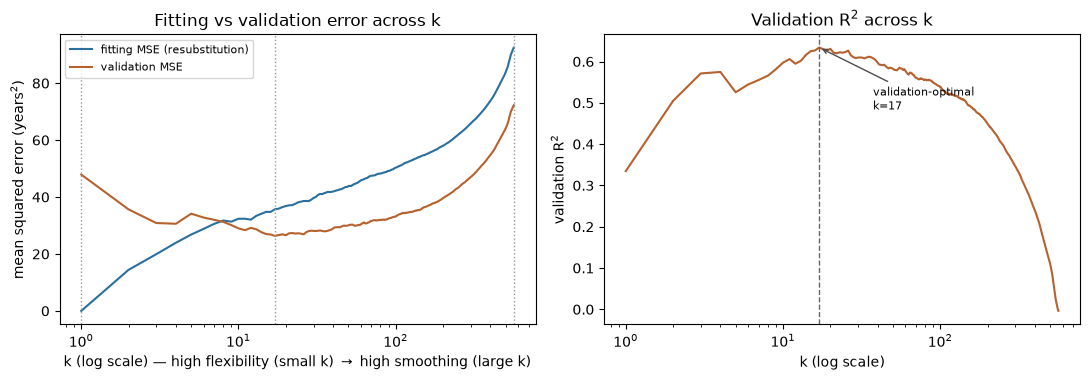

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))

ax = axes[0]
ax.plot(ks, fit_mse, label="fitting MSE (resubstitution)", color="#2a6f9e")
ax.plot(ks, val_mse, label="validation MSE", color="#b5622f")
ax.set_xscale("log")
ax.set_xlabel("k (log scale) \u2014 high flexibility (small k) $\\to$ high smoothing (large k)")
ax.set_ylabel("mean squared error (years$^2$)")
for k_mark, label in [(1, "k=1"), (val_optimal_k, "validation-optimal"), (N_FIT, "k=N_fit")]:
    ax.axvline(k_mark, color="0.6", lw=1, ls=":")
ax.legend(fontsize=8)
ax.set_title("Fitting vs validation error across k")

ax = axes[1]
ax.plot(ks, val_r2, color="#b5622f")
ax.axvline(val_optimal_k, color="0.4", lw=1, ls="--")
ax.annotate(f"validation-optimal\nk={val_optimal_k}", xy=(val_optimal_k, val_r2[val_optimal_k - 1]),
            xytext=(val_optimal_k * 2.2, val_r2[val_optimal_k - 1] - 0.15), fontsize=8,
            arrowprops=dict(arrowstyle="->", color="0.3"))
ax.set_xscale("log")
ax.set_xlabel("k (log scale)")
ax.set_ylabel("validation R$^2$")
ax.set_title("Validation R$^2$ across k")

plt.tight_layout(); plt.show()

```{admonition} What this curve shows -- and does not
:class: note
Fitting error keeps falling as `k` shrinks (perfect at `k = 1`, exactly the
resubstitution optimism Section 3 demonstrated) while validation error is
lowest at an intermediate `k` and rises again toward both ends -- **behaviour
consistent with** the bias–variance tradeoff. It does not **directly
estimate** bias and variance: the true population relationship between
cortical structure and age is unknown, and this is one observational sample,
not repeated draws from that population. The validation-optimal `k` here
(17) also need not match the training-only cross-validated `k` from
Section 2 (15) -- they come from different splits of different data and are
not meant to agree exactly.

This development curve is exploratory. It never retunes or replaces the
Section 2 model: the outer test set stays locked, and the `k = 15` reported
there is the notebook's one honest number.
```

## 6. Explore k yourself

The activity below lets you move the same `k` from 1 through `N_fit`
yourself, on the same fitting/validation split as Section 5. Every plot and
every number recomputes from the actual refitted model at your chosen `k` --
nothing is a canned label. It runs entirely in the browser, offline, with no
brain features or participant identifiers ever sent anywhere.


<iframe
  title="Interactive KNN neighbour-count exploration for predicting age from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/knn_explore.json"
  loading="lazy"
  width="100%"
  height="1500"
  class="ml-activity"
  style="width: 100%;"
></iframe>

```{admonition} Think first
:class: note
1. Move `k` from 1 up toward 20–30. What happens to the *gap* between the
   fitting curve and the validation curve, and why is that gap the same
   phenomenon Section 3 demonstrated with a single fixed `k`?
2. Move `k` all the way to its maximum. Confirm every point in the scatter
   plot lands on one horizontal line. What is that line?
3. Find the `k` with the lowest validation error in the activity. Is it
   exactly `k = 15`, the model Section 2 reports? Should it be?
```

## In summary

- KNN regression predicts by averaging the `k` nearest training
  participants' outcomes; `k` directly controls flexibility.
- Choosing `k` by cross-validation on the training partition only, then
  evaluating once on a locked test set, is the same honest workflow Exercise
  2 used for linear regression -- only the model family changed.
- Resubstitution and leakage inflate performance the same way they did for
  linear regression; how *dramatically* they inflate it depends on `k`
  (mild at `k = 15`, extreme -- and exactly, trivially perfect -- at
  `k = 1`).
- Small `k` means low bias and high variance; large `k` means higher bias
  and low variance; training error alone cannot choose between them.
- An empirical fitting/validation curve computed from real data is
  **consistent with** the bias–variance tradeoff without being a direct
  measurement of it -- the population relationship is unknown and only one
  sample is available.

Next practice: classification, where KNN votes among neighbours' labels
instead of averaging their values.


### Questions to take away

1. What happens to flexibility when `k` increases?
2. Why can `k = 1` achieve perfect training performance?
3. Why is that not evidence of good generalisation?
4. What does `k = N_fit` predict for every new participant?
5. Why must scaling be learned only from training data, exactly as in
   Exercise 2?
6. Why is a validation curve computed from one dataset not a direct
   measurement of bias and variance?
7. Would the `k` selected here necessarily generalise to a completely new
   scanning site? Why or why not?
